# fMRI preprocessing overlap check

This notebook loads the raw fMRI image and the preprocessed image, then overlays
both with the AAL3 and Schaefer2018 templates to visually check alignment.

In [8]:
import os
import numpy as np
import nibabel as nib
from nilearn import image, plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.input_data import NiftiLabelsMasker
import matplotlib.pyplot as plt

## Input paths
Update these paths if files move.

In [9]:
raw_fmri_path = "/home/martin/data/UNSAM/CEMSC3/MateriaNeurocienciaComputacional/2026/Tutorial/datos_clean/CP0118/funcional_3s_30te_2_4_iso_estric__s014.nii.gz"
preproc_fmri_path = "/home/martin/data_imaging/CovidProject/FullStudy/fMRI/FunImgARWSDCFN/CP0118/Filtered_4DVolume.nii.nii"
aal3_path = "/home/martin/data/UNSAM/CEMSC3/MateriaNeurocienciaComputacional/2026/Tutorial/datos_clean/templates/AAL3v1_1mm.nii.gz"
schaefer_path = "/home/martin/data/UNSAM/CEMSC3/MateriaNeurocienciaComputacional/2026/Tutorial/datos_clean/templates/Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_1mm.nii.gz"

for label, path in {
    'Raw fMRI': raw_fmri_path,
    'Preprocessed fMRI': preproc_fmri_path,
    'AAL3': aal3_path,
    'Schaefer': schaefer_path,
}.items():
    if not os.path.exists(path):
        print(f'⚠️ Missing {label} file: {path}')

## Load images
We load the raw fMRI, the preprocessed fMRI, and both templates. For the fMRI files,
we take the first volume to visualize alignment in 3D.

In [10]:
raw_img_4d = nib.load(raw_fmri_path)
preproc_img_4d = nib.load(preproc_fmri_path)
aal3_img = nib.load(aal3_path)
schaefer_img = nib.load(schaefer_path)

raw_img = image.index_img(raw_img_4d, 0)
preproc_img = image.index_img(preproc_img_4d, 0)

print('Raw fMRI shape:', raw_img_4d.shape)
print('Preprocessed fMRI shape:', preproc_img_4d.shape)
print('AAL3 template shape:', aal3_img.shape)
print('Schaefer template shape:', schaefer_img.shape)

Raw fMRI shape: (88, 88, 50, 200)
Preprocessed fMRI shape: (91, 109, 91, 200)
AAL3 template shape: (181, 217, 181)
Schaefer template shape: (182, 218, 182)


## Visualize raw vs preprocessed slices
These quick views let you confirm orientation and basic alignment.

/home/martin/.local/lib/python3.10/site-packages/nilearn/image/resampling.py:809: UserWarning: Casting data from int32 to float32
  return resample_img(


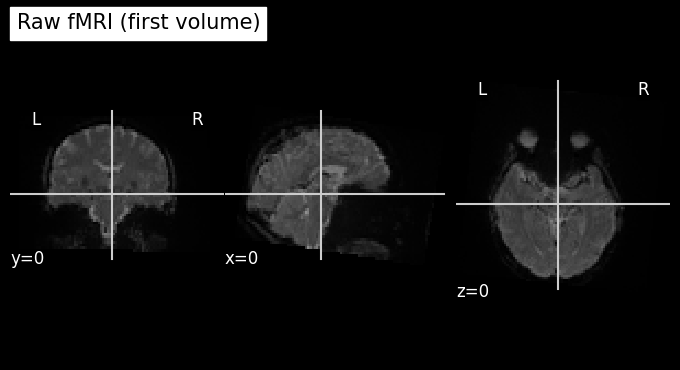

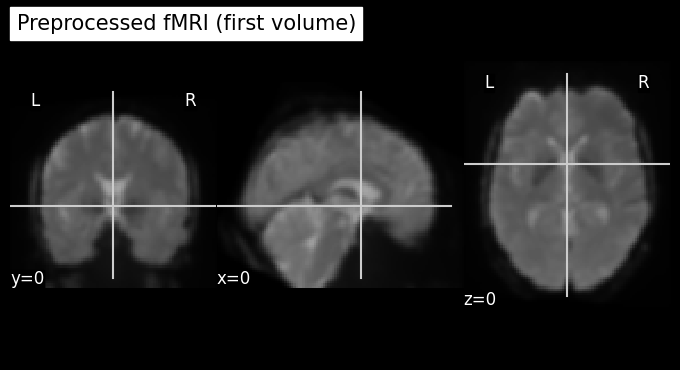

In [11]:
plotting.plot_anat(raw_img, title='Raw fMRI (first volume)', display_mode='ortho', cut_coords=(0, 0, 0))
plotting.plot_anat(preproc_img, title='Preprocessed fMRI (first volume)', display_mode='ortho', cut_coords=(0, 0, 0))
plotting.show()

## Tissue-segmented raster plot (raw fMRI)
We load a tissue segmentation (GM=2, WM=3), extract voxelwise time series from the **raw** fMRI, and plot a raster with GM voxels first followed by WM voxels.

In [ ]:
seg_path = "/home/martin/data/UNSAM/CEMSC3/MateriaNeurocienciaComputacional/2026/Tutorial/data/CP0118/t1_robustfov_brain_seg.nii.gz"
seg_img = nib.load(seg_path)
seg_data = seg_img.get_fdata()

raw_data = raw_img_4d.get_fdata()
if raw_data.ndim != 4:
    raise ValueError("Raw fMRI must be 4D to extract voxel time series.")

gm_mask = seg_data == 2
wm_mask = seg_data == 3

gm_ts = raw_data[gm_mask, :]
wm_ts = raw_data[wm_mask, :]

max_voxels = 2000
if gm_ts.shape[0] > max_voxels:
    gm_ts = gm_ts[np.random.choice(gm_ts.shape[0], max_voxels, replace=False)]
if wm_ts.shape[0] > max_voxels:
    wm_ts = wm_ts[np.random.choice(wm_ts.shape[0], max_voxels, replace=False)]

raster = np.vstack([gm_ts, wm_ts])
gm_count = gm_ts.shape[0]

plt.figure(figsize=(10, 6))
plt.imshow(raster, aspect="auto", cmap="viridis", interpolation="nearest")
plt.axhline(gm_count - 0.5, color="white", linewidth=1, linestyle="--")
plt.title("Raw fMRI voxel raster: GM (top) then WM (bottom)")
plt.xlabel("Time (volumes)")
plt.ylabel("Voxels (GM first, WM second)")
plt.colorbar(label="Signal intensity")
plt.show()

## Resample templates to preprocessed space
Templates are resampled to the preprocessed fMRI grid so overlays match voxel space.

In [12]:
aal3_resampled = image.resample_to_img(aal3_img, preproc_img, interpolation='nearest')
schaefer_resampled = image.resample_to_img(schaefer_img, preproc_img, interpolation='nearest')

print('Resampled AAL3 shape:', aal3_resampled.shape)
print('Resampled Schaefer shape:', schaefer_resampled.shape)

Resampled AAL3 shape: (91, 109, 91)
Resampled Schaefer shape: (91, 109, 91)


## Overlay templates on preprocessed fMRI
These overlays help check if the template boundaries align with the subject image.

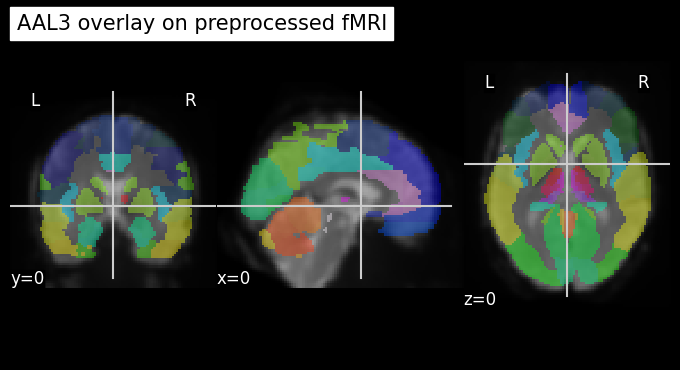

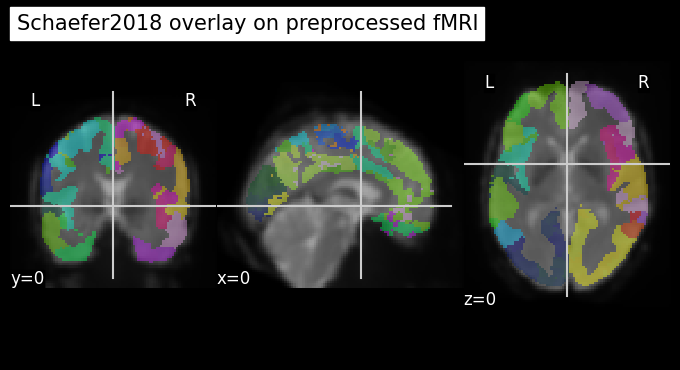

In [13]:
plotting.plot_roi(
    aal3_resampled,
    bg_img=preproc_img,
    title='AAL3 overlay on preprocessed fMRI',
    display_mode='ortho',
    cut_coords=(0, 0, 0),
    alpha=0.4
)
plotting.plot_roi(
    schaefer_resampled,
    bg_img=preproc_img,
    title='Schaefer2018 overlay on preprocessed fMRI',
    display_mode='ortho',
    cut_coords=(0, 0, 0),
    alpha=0.4
)
plotting.show()

## Connectivity matrices per template
We extract ROI time series from the preprocessed fMRI, compute correlation matrices, and visualize them for AAL3 and Schaefer templates.

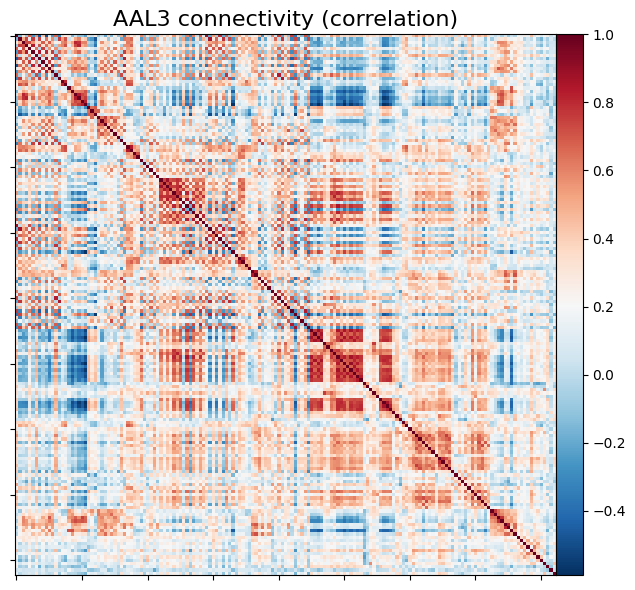

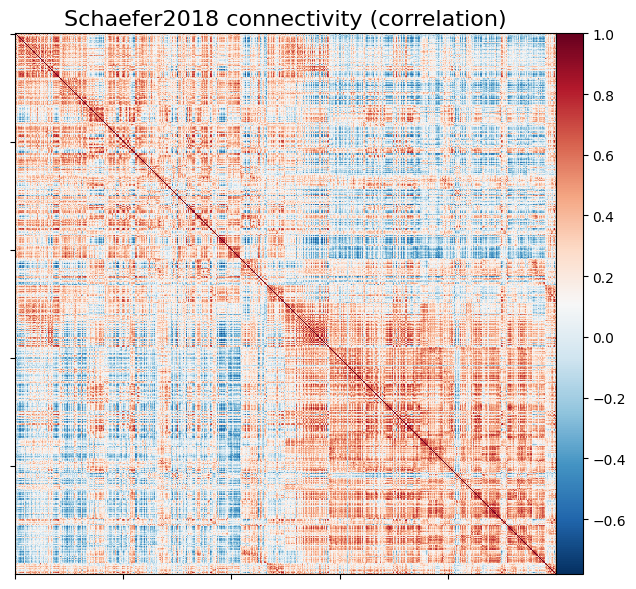

In [14]:
def compute_connectivity(fmri_4d, atlas_img, atlas_name):
    if len(fmri_4d.shape) < 4 or fmri_4d.shape[3] < 2:
        raise ValueError(f"{atlas_name}: fMRI input must be 4D with time dimension.")
    masker = NiftiLabelsMasker(labels_img=atlas_img, standardize=True)
    time_series = masker.fit_transform(fmri_4d)
    conn_measure = ConnectivityMeasure(kind="correlation")
    conn_matrix = conn_measure.fit_transform([time_series])[0]
    return conn_matrix, time_series

# Compute connectivity for AAL3
aal3_conn, aal3_ts = compute_connectivity(preproc_img_4d, aal3_resampled, "AAL3")
plotting.plot_matrix(aal3_conn, figure=(8, 6), title="AAL3 connectivity (correlation)")
plt.show()

# Compute connectivity for Schaefer
schaefer_conn, schaefer_ts = compute_connectivity(preproc_img_4d, schaefer_resampled, "Schaefer2018")
plotting.plot_matrix(schaefer_conn, figure=(8, 6), title="Schaefer2018 connectivity (correlation)")
plt.show()

## Example ROI time series (high vs low correlation)
We pick two ROI pairs from the AAL3 connectivity matrix: one with high correlation and one with low correlation, then plot their BOLD signals.

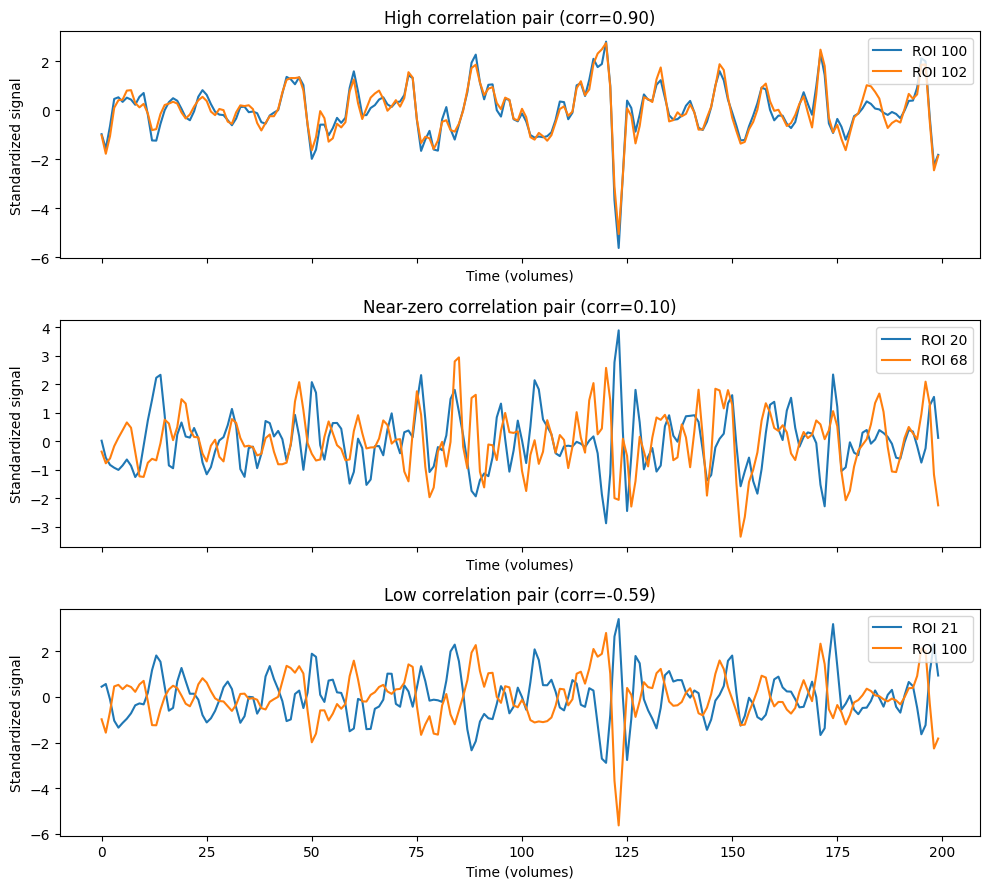

In [18]:
# Use AAL3 connectivity to select ROI pairs
conn = aal3_conn
ts = aal3_ts
n_rois = conn.shape[0]
upper = np.triu(np.ones_like(conn, dtype=bool), k=1)
rows, cols = np.where(upper)

corr_vals = conn[rows, cols]
max_idx = np.argmax(corr_vals)
min_idx = np.argmin(corr_vals)

# Find pair with correlation near 0.1
abs_corr = np.abs(corr_vals)
near_zero_idx = np.argmin(np.abs(abs_corr - 0.1))

high_pair = (rows[max_idx], cols[max_idx])
low_pair = (rows[min_idx], cols[min_idx])
near_zero_pair = (rows[near_zero_idx], cols[near_zero_idx])

def plot_pair(pair, title_prefix, ax):
    i, j = pair
    ax.plot(ts[:, i], label=f"ROI {i}")
    ax.plot(ts[:, j], label=f"ROI {j}")
    ax.set_title(f"{title_prefix} (corr={conn[i, j]:.2f})")
    ax.set_xlabel("Time (volumes)")
    ax.set_ylabel("Standardized signal")
    ax.legend(loc="upper right")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
plot_pair(high_pair, "High correlation pair", axes[0])
plot_pair(near_zero_pair, "Near-zero correlation pair", axes[1])
plot_pair(low_pair, "Low correlation pair", axes[2])
plt.tight_layout()
plt.show()

## Optional: save figures
Uncomment to export figures for a manuscript or report.

In [15]:
# output_dir = "/home/martin/data/UNSAM/CovidProject/longcovid-neuroimaging-cohort/data/plots"
# os.makedirs(output_dir, exist_ok=True)
# plotting.plot_anat(raw_img, title='Raw fMRI', display_mode='ortho', cut_coords=(0, 0, 0),
#                  output_file=os.path.join(output_dir, 'raw_fmri_ortho.png'))
# plotting.plot_anat(preproc_img, title='Preprocessed fMRI', display_mode='ortho', cut_coords=(0, 0, 0),
#                  output_file=os.path.join(output_dir, 'preproc_fmri_ortho.png'))
# plotting.plot_roi(aal3_resampled, bg_img=preproc_img, title='AAL3 overlay', display_mode='ortho',
#                   cut_coords=(0, 0, 0), alpha=0.4,
#                   output_file=os.path.join(output_dir, 'aal3_overlay.png'))
# plotting.plot_roi(schaefer_resampled, bg_img=preproc_img, title='Schaefer overlay', display_mode='ortho',
#                   cut_coords=(0, 0, 0), alpha=0.4,
#                   output_file=os.path.join(output_dir, 'schaefer_overlay.png'))